In [1]:
%load_ext autoreload
%autoreload 2

import uproot
import numpy as np
import matplotlib.pyplot as plt
import awkward as ak
import glob, re
from matplotlib import colors
from scipy.optimize import curve_fit
from scipy.stats import chi2
import pickle
from tqdm import tqdm
import time
from datetime import datetime
plt.style.use('dark_background')

import sys
import importlib
from pathlib import Path
# --- find repo root (walks up until it finds the extern/ submodule dir) ---
repo_root = Path.cwd()
print(repo_root)
while not (repo_root / "extern").exists():
    repo_root = repo_root.parent

geometry_path = repo_root / "extern" / "Geometry"
timecal_path  = repo_root / "extern" / "TimeCal"

sys.path.insert(0, str(repo_root / "extern"))  
sys.path.insert(0, str(geometry_path))
sys.path.insert(0, str(timecal_path))
sys.path.insert(0, str(repo_root))

# --- project imports ---
from analysis_tools import DataLoader
from analysis_tools import BeamSelection, Cut, print_cherenkov_thresholds, SelectionMonitor
from Geometry.Device import Device
from TimeCal.TC_Multilaterator import TC_Multilaterator
from TimeCal.TC_BeaconData import TC_BeaconData

/eos/home-j/jazhang/analysis_tools/analysis_examples


## Load merged data production file and get information from BeamSelection class 

In [2]:
run_number = 1478    # (-410 MeV/c, pre-hardware trigger)
file_path = f"/eos/experiment/wcte/data/2025_commissioning/processed_offline_data/production_v1_0/{run_number}/WCTE_merged_production_R{run_number}.root"

loader = DataLoader(file_path)
vme_run_info = loader.get_vme_analysis_run_info()
print_cherenkov_thresholds(vme_run_info)

Run momentum : 410 MeV/c
n (act_eveto)  = 1.0100   n (act_tagger) = 1.0600

Particle   Mass [MeV]   Thresh. ACT eveto [MeV]  Above?   Thresh. ACT tagger [MeV]  Above?
------------------------------------------------------------------------------------------
electron        0.511                      3.6     yes                       1.5     yes
muon          105.660                    745.3      no                     300.5     yes
pion          139.570                    984.5      no                     397.0     yes
kaon          493.680                   3482.2      no                    1404.2      no
proton        938.270                   6618.0      no                    2668.8      no
deuteron     1876.540                  13236.1      no                    5337.6      no
helium3      2808.390                  19808.9      no                    7988.2      no


## Define particle selection
- Every VME variable cut is a [variable, operator, value] triplet.
- Omit the TOF cut entirely if proton_tof_cut is 0. This case of TOF separation unavailable happens for negative polarity and low momentum runs in production 1.0.
- Please see [analysis_examples README](https://github.com/WCTE/analysis_tools/blob/main/analysis_examples/README.md) and [Example Using Data Loader.ipynb](https://github.com/WCTE/analysis_tools/blob/main/analysis_examples/Example%20Using%20Data%20Loader.ipynb) for more details.

In [3]:
vme_scalar_results = loader.get_vme_analysis_scalar_results()

tof_cut    = vme_scalar_results['proton_tof_cut']
if tof_cut == 0:
    print("WARNING: TOF separation unavailable for this run, setting TOF cut to default value of 999 ns.\n")
    tof_cut = 999

eveto_cut  = vme_scalar_results['act_eveto_cut']
tagger_cut = vme_scalar_results['act_tagger_cut']

# MUONS: fast particles, below threshold in act_eveto, above threshold in act_tagger,
muon_sel = BeamSelection.selection("muon",
    ["vme_act_eveto",  "<", eveto_cut],
    ["vme_act_tagger", ">", tagger_cut],
    ["vme_tof_corr",   "<", tof_cut],
)

# ELECTRONS: fast particles above threshold in the upstream ACT (act_eveto).
elec_sel = BeamSelection.selection("electron",
    ["vme_act_eveto", ">", eveto_cut],
    ["vme_tof_corr",  "<", tof_cut],
)

muon_sel.describe()


Selection : muon
  vme_act_eveto          < 1.51 PE  [below threshold]
  vme_act_tagger         > 21.4 PE  [above threshold]
  vme_tof_corr           < 999 ns  [below threshold]


## Use DataLoader and BeamSelection to select muons

In [6]:
particle_type = "muon"  # change to filter for different particles
# specify output file 
output_file = repo_root/"analysis_examples"/f"{particle_type}_filtered_R{run_number}_v1_0_{datetime.now().date()}.root"

# Branches to load 
branches_to_load = [
    "window_time", "start_counter", "run_id", "sub_run_id", "spill_counter", "event_number", "readout_number",
     # beam side 
    "vme_act_eveto", "vme_act_tagger", "vme_tof_corr",
    # tank side
    "hit_mpmt_slot_ids", "hit_pmt_position_ids", "hit_pmt_charges", "hit_pmt_calibrated_times",
    "hit_pmt_readout_mask", 
    # T5
    "T5_hit_time", "T5_secondary_hit_is_in_bounds", "T5_secondary_hit_time"]

selections = {
    "muon": muon_sel,
    "electron": elec_sel
}

loader = DataLoader(file_path, branches_to_load=branches_to_load)
# enable DataLoader cuts
loader.apply_vme_event_quality_cuts()
loader.apply_t5_event_quality_cuts()
loader.apply_mPMT_data_quality_cuts()

total_events_processed = 0
total_particles_selected = 0
tree = None

with uproot.recreate(output_file) as fout: 
    with tqdm(unit=" events", desc=f"Filtering {particle_type}s") as pbar:

        iterator = loader.iterate(step_size="300 MB")

        for batch in iterator:

            n_before = len(batch["event_number"])
            total_events_processed += n_before

            # particle selection
            mask_pid = selections[particle_type].mask(batch)
            batch_final = batch[mask_pid]

            n_after = len(batch_final)
            total_particles_selected += n_after

            if n_after == 0:
                pbar.update(n_before)
                continue

            data_to_write = {b: batch_final[b] for b in branches_to_load}

            if tree is None:
                #fout["WCTEReadoutWindows"] = data_to_write
                fout.mktree("WCTEReadoutWindows", data_to_write)
                tree = fout["WCTEReadoutWindows"]
            else:
                tree.extend(data_to_write)

            pbar.set_postfix({
                "processed": total_events_processed,
                "selected": total_particles_selected
            })

            pbar.update(n_before)

print(f"Output written to: {output_file}")

Filtering muons: 342394 events [06:51, 832.54 events/s, processed=342394, selected=10759] 

Output written to: /eos/home-j/jazhang/analysis_tools/analysis_examples/muon_filtered_R1478_v1_0_2026-06-16.root


## Load processed particle selection 

We will select muons by making a histogram of the PMT calibrated hit times in the run. We will find the largest peak in this histogram and require beam muons to arrive within 100 ns of this peak. 

In [7]:
# change these variables as needed if loading a different particle selection file 
run_number = 1478  
particle_type = "muon"
date = datetime.now().date() 

with uproot.open(f"{particle_type}_filtered_R{run_number}_v1_0_{date}.root") as f:
    all_mu_events = f["WCTEReadoutWindows"].arrays(library="ak")

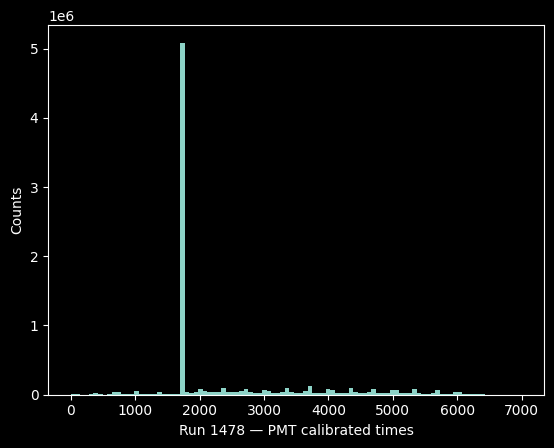

Global peak time: 1709.0 ns
Prompt event window: [1659.0, 1759.0] ns


In [8]:
all_times = []
all_times = np.concatenate([ak.to_numpy(event['hit_pmt_calibrated_times']) for event in all_mu_events])
plt.hist(np.array(all_times), bins=np.linspace(0, 7000, 100));
plt.xlabel(f"Run {run_number} — PMT calibrated times")
plt.ylabel("Counts")
plt.show()

# choose histogram binning
global_bins = np.arange(0, np.percentile(all_times, 99.9), 1) # 1 ns bins
global_values, global_edges = np.histogram(all_times, bins=global_bins)
# find largest peak 
global_peak_time = float(global_edges[np.argmax(global_values)])
# define 100 ns window around peak
global_window_min = global_peak_time - 50
global_window_max = global_peak_time + 50
print(f"Global peak time: {global_peak_time:.1f} ns")
print(f"Prompt event window: [{global_window_min:.1f}, " f"{global_window_max:.1f}] ns")

## Multilaterate 

We will use the multilaterator to reconstruct the position and time of Michel electron candidates. The search algorithm per event is as follows: 

- Define a search window
- Find the beam muon according to the method described above
- Look 200 ns after the beam muon time, taking the largest peak in that time window to be the Michel electron candidate
- Run multilaterator on Michel electron candidates and save output

Please see the example notebook [multilaterate_wcte.ipynb](https://github.com/WCTE/TimeCal/blob/main/examples/multilaterate_wcte.ipynb) for more details on how the multilaterator works. 

In [10]:
# create multilaterator 
hall = Device.open_file('../../Geometry/examples/wcte_bldg157.geo')
wcte = hall.wcds[0]
my_multilaterator = TC_Multilaterator(wcte, refraction_index=1.373)
michel_results = []
failed_events = []

# define search window 
window_min = 1000
window_max = 7500
window_bins = np.arange(window_min, window_max, 1)
prompt_bins = np.arange(global_window_min, global_window_max, 1) # 1 ns bins 

# precompute position lookup
position_lookup = {}
for i_mpmt, mpmt in enumerate(wcte.mpmts):
    for i_pmt, pmt in enumerate(mpmt.pmts):
        pos = pmt.get_placement('design', wcte)['location']
        position_lookup[(i_mpmt, i_pmt)] = np.array([pos[0], pos[1], pos[2]])
        
# loop to multilaterate 
for evID, event in tqdm(enumerate(all_mu_events), total=len(all_mu_events),desc="Multilaterating events"):

    event_times   = ak.to_numpy(event['hit_pmt_calibrated_times'])
    event_mpmts   = ak.to_numpy(event['hit_mpmt_slot_ids'])
    event_pmts    = ak.to_numpy(event['hit_pmt_position_ids'])
    event_charges = ak.to_numpy(event['hit_pmt_charges'])
    event_number  = int(event['event_number'])

    pre_hit_mask = ((event_times > window_min) & (event_times < window_max))
    pre_times = event_times[pre_hit_mask]
    if len(pre_times) == 0:
        print(f"NO HITS IN SEARCH WINDOW [{window_min}, {window_max}] ns for Event {evID}!")
        failed_events.append({"event_id": evID, "reason": "no_hits"})
        continue

    # prompt muon search 
    prompt_mask = ((event_times > global_window_min) & (event_times < global_window_max))
    prompt_times = event_times[prompt_mask]

    if len(prompt_times) == 0:
        print(f"No PROMPT EVENT found in [{window_min}, {window_max}] ns for Event {evID}")
        failed_events.append({"event_id": evID, "reason": "no_prompt"})
        continue

    p_hist_values, p_hist_edges = np.histogram(prompt_times, bins=prompt_bins)
    peak_idx = np.argmax(p_hist_values)
    mu_peak_time = p_hist_edges[peak_idx]
    mu_peak_counts = p_hist_values[peak_idx]

    # michel electron search 
    michel_min = mu_peak_time + 200
    michel_max = window_max

    michel_search_mask = ((event_times > michel_min) & (event_times < michel_max))
    michel_search_times = event_times[michel_search_mask]

    if len(michel_search_times) == 0:
        print(f"NO MICHEL CANDIDATE in [{michel_min}, {michel_max}] ns for Event {evID}")
        failed_events.append({"event_id": evID, "reason": "no_michel"})
        continue

    michel_bins = np.arange(michel_min, michel_max, 1)
    values, edges = np.histogram(michel_search_times, bins=michel_bins)
    peak_time = edges[np.argmax(values)]
    
    # min/max around michel peak 
    min_time = peak_time - 8
    max_time = peak_time + 4
    
    hit_mask = ((event_times > min_time) & (event_times < max_time))
    mpmts  = event_mpmts[hit_mask]
    pmts   = event_pmts[hit_mask]
    charges = event_charges[hit_mask]
    times   = event_times[hit_mask]
    nhits = len(mpmts)

    if nhits <= 30:
        continue

    # build beacon for multilaterator 
    michel_data = TC_BeaconData(f'michel run {run_number} evt {evID}')
    t_sig = 0.01
    hit_positions = np.empty((nhits, 3))

    for i, (i_mpmt, i_pmt, t) in enumerate(zip(mpmts, pmts, times)):
        michel_data.add_signal(i_mpmt, i_pmt, t, t_sig)
        hit_positions[i] = position_lookup[(i_mpmt, i_pmt)]

    my_multilaterator.assign_data(michel_data, calibrated=True, use_tts=True)
    guess = (0., 0., 0., peak_time)
    mins = (-4000., -4000., -4000., peak_time-100)
    maxs = (4000., 4000., 4000., peak_time+100)

    try:
        result, cov, chi_2, n_dof = (my_multilaterator.multilaterate(guess,mins,maxs,method="trf",loss="huber"))
    except Exception as e:
        print(f'multilaterator failed: {e}')
        failed_events.append({"event_id": evID, "reason": "multilateration_exception", "error": str(e)})
        continue

    # store result 
    total_charge = np.sum(charges)
    michel_result = {
        'x': result.x[0],
        'y': result.x[1],
        'z': result.x[2],
        't': result.x[3],
        'sx': np.sqrt(cov[0][0]),
        'sy': np.sqrt(cov[1][1]),
        'sz': np.sqrt(cov[2][2]),
        'st': np.sqrt(cov[3][3]),
        'cov': cov,
        'chi2': chi_2,
        'ndof': n_dof,
        'mu_time': mu_peak_time,
        'charges': charges,
        'nhits': nhits,
        'total_charge': total_charge,
        'event_number': event_number, 
        'event_id': evID,
        'hit_positions': hit_positions
    }

    michel_results.append(michel_result)
    
multilaterator_res = {"successful_events": michel_results, "failed_events": failed_events}
# save results to unpickle later 
with open(repo_root/"analysis_examples"/f"multilaterator_res_run{run_number}_{particle_type}_{date}.pkl", "wb") as f:
    pickle.dump(multilaterator_res, f)

Multilaterating events:   4%|█                           | 391/10759 [00:05<02:30, 68.69it/s]

NO MICHEL CANDIDATE in [1911.0, 7500] ns for Event 391


Multilaterating events:   8%|██▏                         | 821/10759 [00:11<02:30, 65.92it/s]

NO MICHEL CANDIDATE in [1901.0, 7500] ns for Event 815


Multilaterating events:  27%|███████▏                   | 2879/10759 [00:39<01:50, 71.51it/s]

...

Multilaterating events:  41%|███████████                | 4386/10759 [00:58<01:49, 58.32it/s]

NO MICHEL CANDIDATE in [1911.0, 7500] ns for Event 4380


Multilaterating events:  96%|████████████████████████▉ | 10343/10759 [02:16<00:05, 82.53it/s]

NO MICHEL CANDIDATE in [1903.0, 7500] ns for Event 10332


Multilaterating events: 100%|██████████████████████████| 10759/10759 [02:22<00:00, 75.75it/s]


In [11]:
# load multilaterator results
print(f"Loading run: {run_number}\nParticle type: {particle_type}")
with open(f"multilaterator_res_run{run_number}_{particle_type}_{date}.pkl", "rb") as f:
    multilaterator_res = pickle.load(f)

michel_results = multilaterator_res["successful_events"]
failed_events = multilaterator_res["failed_events"]
print(f"Loaded {len(michel_results)} successful events")

Loading run: 1478
Particle type: muon


FileNotFoundError: [Errno 2] No such file or directory: 'multilaterator_res_run1478_muon_2026-06-16.pkl'

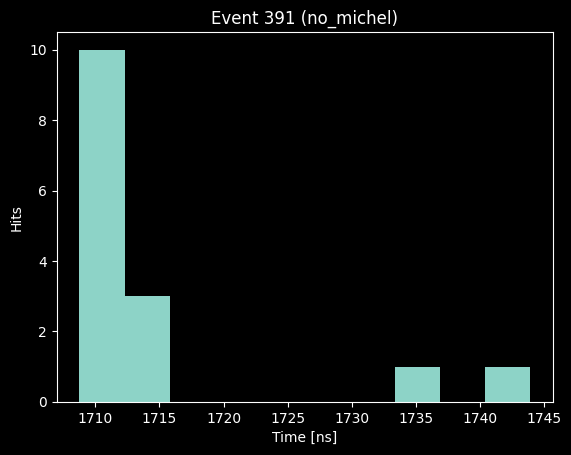

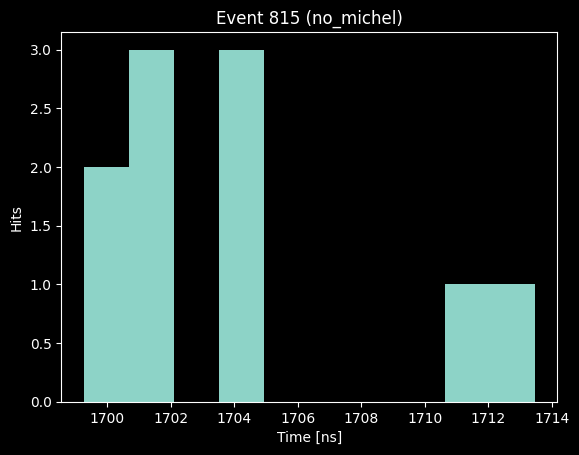

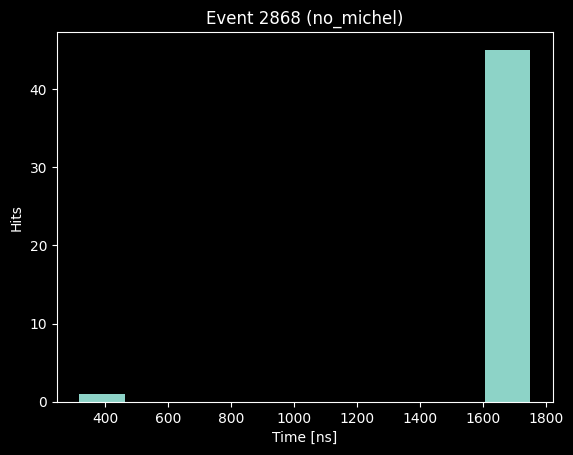

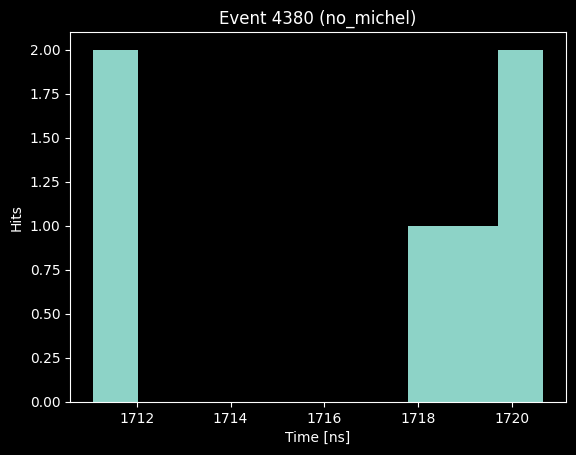

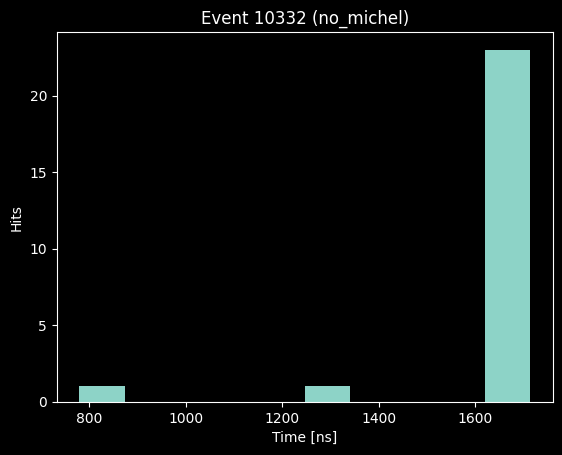

In [ ]:
# look at time distribution of failed events
for failed in failed_events[:len(failed_events)]:  

    evID = failed["event_id"]
    reason = failed["reason"]

    event = all_mu_events[evID]
    times = ak.to_numpy(event["hit_pmt_calibrated_times"])

    plt.figure()
    plt.hist(times)
    plt.xlabel("Time [ns]")
    plt.ylabel("Hits")
    plt.title(f"Event {evID} ({reason})")
    plt.show()

We can check how many events have a secondary hit in T5 within the time we look for the Michel electron candidate. We can remove these instances of beam pileup by placing a cut on T5 secondary hit time since it occurs less than 5% of the time throughout this particular run.

In [ ]:
WINDOW_NS = 8000 
n_with_secondary = 0
n_without_secondary = 0
evID_with_secondary = []

for evID, event in enumerate(all_mu_events):

    t5_time = float(event['T5_hit_time'][0])

    secondary_times = ak.to_numpy(event['T5_secondary_hit_time'])
    in_bounds = ak.to_numpy(event['T5_secondary_hit_is_in_bounds'])

    mask = (
        (secondary_times >= t5_time) &
        (secondary_times <= t5_time + WINDOW_NS) &
        (in_bounds)
    )
    hits_in_window = secondary_times[mask]
    
    if len(hits_in_window) > 0:
        evID_with_secondary.append(evID)
        n_with_secondary += 1
    else:
        n_without_secondary += 1

print(f"Events WITH secondary hit within {WINDOW_NS} ns: {n_with_secondary}")
print(f"Events WITHOUT secondary hit within {WINDOW_NS} ns: {n_without_secondary}")
print(f"Fraction with secondary hits: "
      f"{n_with_secondary / (n_with_secondary + n_without_secondary):.3f}")

Events WITH secondary hit within 8000 ns: 507
Events WITHOUT secondary hit within 8000 ns: 10252
Fraction with secondary hits: 0.047


We will place additional cuts on nhits and charge for a purer Michel electron selection.

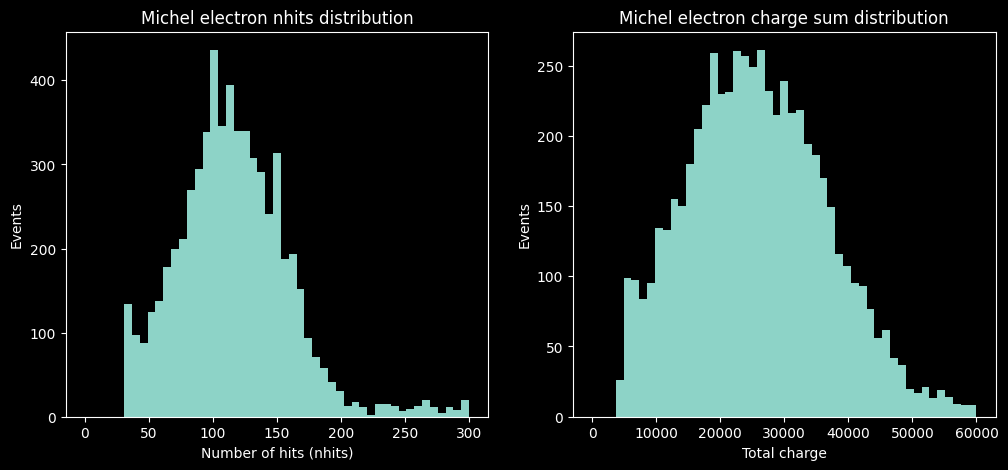

In [ ]:
nhits_list = [res['nhits'] for res in michel_results]
charges = [res['total_charge'] for res in michel_results]

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# nhits histogram
axes[0].hist(nhits_list, bins=np.linspace(0, 300, 50))
axes[0].set_xlabel('Number of hits (nhits)')
axes[0].set_ylabel('Events')
axes[0].set_title('Michel electron nhits distribution')

# charge histogram
axes[1].hist(charges, bins=np.linspace(0, 60000, 50))
axes[1].set_xlabel('Total charge')
axes[1].set_ylabel('Events')
axes[1].set_title('Michel electron charge sum distribution')

plt.show()

Let's check how the multilateration went by reproducing some plots from [Dean's multilaterator example](https://github.com/WCTE/LicketyFit/blob/main/examples/display_events_from_sahar.ipynb)

Fit results:
N0  = 615.79 ± 27.90
tau = 1798.26 ± 298.30 ns
c   = 0.00 ± 41.12
Number of events (total): 7706
Events after cuts: 5014


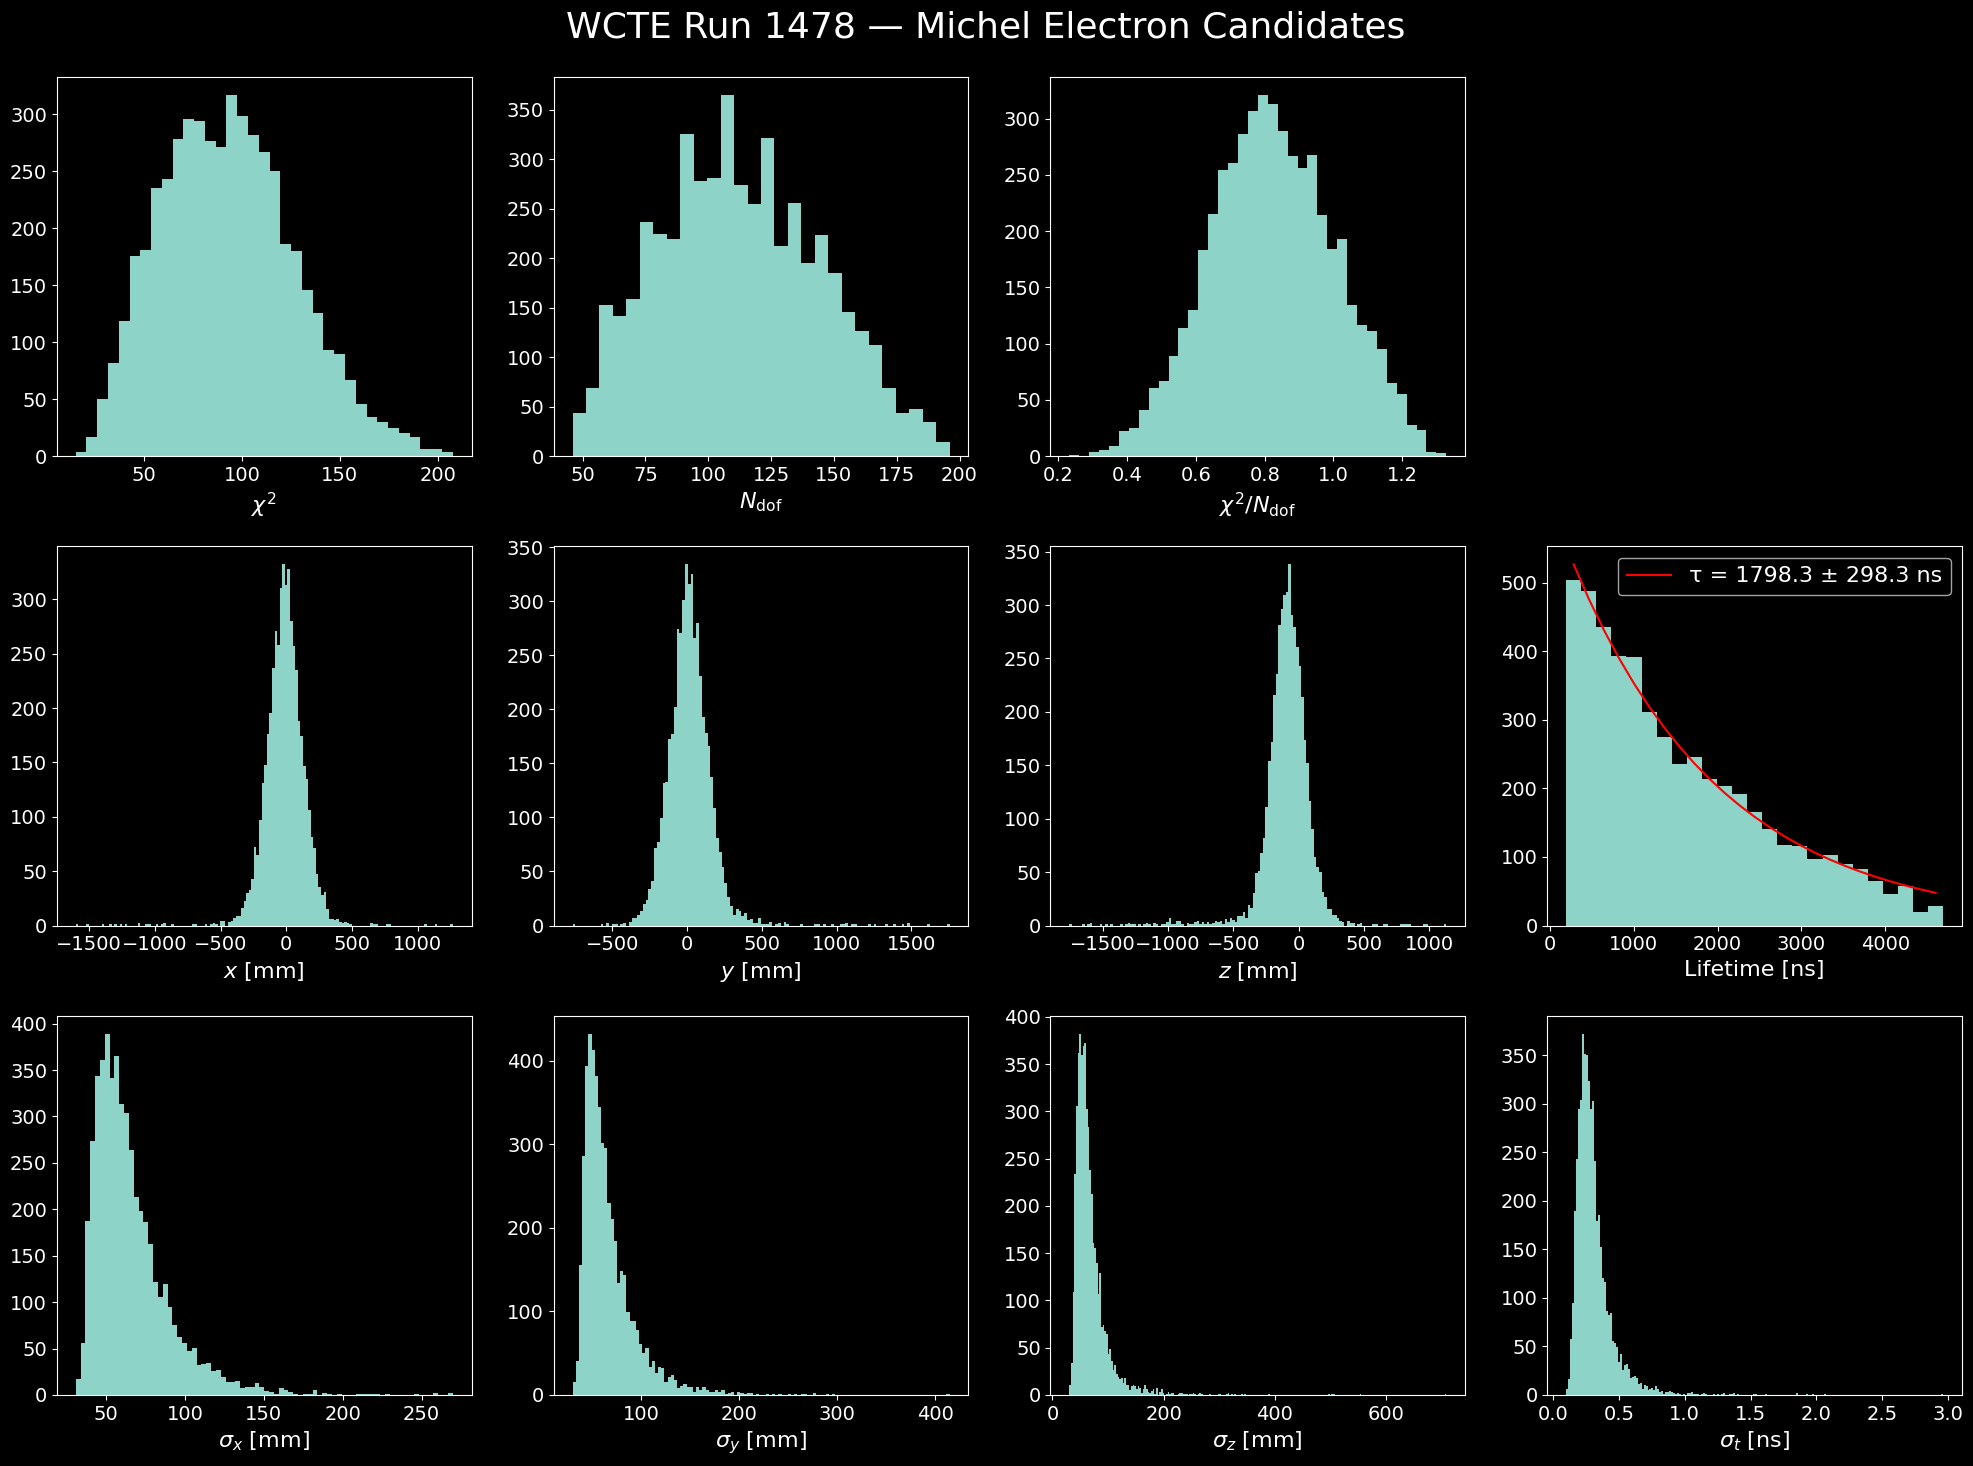

In [ ]:
# for applying cuts on nhits, chargesum, t5 secondary, p-value
def filter_results(michel_results, nhits_min=None, nhits_max=None,
                   chargesum_min=None, chargesum_max=None, 
                   pvalue_min=None, pvalue_max=None, exclude_T5_secondary=True):
    filtered = []
    for m in michel_results:
        if nhits_min is not None and m['nhits'] < nhits_min:
            continue
        if nhits_max is not None and m['nhits'] > nhits_max:
            continue
        if chargesum_min is not None and m['total_charge'] < chargesum_min:
            continue
        if chargesum_max is not None and m['total_charge'] > chargesum_max:
            continue
        if pvalue_min is not None and m.get('p_value') is not None and m['p_value'] < pvalue_min:
            continue
        if pvalue_max is not None and m.get('p_value') is not None and m['p_value'] > pvalue_max:
            continue
        if exclude_T5_secondary and m['event_id'] in evID_with_secondary:
            continue
        filtered.append(m)
    return filtered

# Plot styling
plt.rcParams.update({
    "font.size": 16,
    "axes.labelsize": 16,
    "axes.titlesize": 16,
    "xtick.labelsize": 14,
    "ytick.labelsize": 14,
    "legend.fontsize": 16,
})

# Compute chi2/ndof, lifetime, p value 
for michel_result in michel_results:
    ndof = michel_result['ndof']
    michel_result['chi2/ndof'] = michel_result['chi2'] / ndof
    michel_result['lifetime'] = michel_result['t'] - michel_result['mu_time']
    michel_result['p_value'] = 1 - chi2.cdf(michel_result['chi2'], michel_result['ndof'])

# Exponential decay model
def exp_decay(t, N0, tau, c):
    return N0 * np.exp(-t / tau) + c

def multi_hist(filtered, selections, nhits_min=None, nhits_max=None,
               chargesum_min=None, chargesum_max=None,  
               pvalue_min=None, pvalue_max=None, do_fit=True):
    nrows = len(selections)
    ncols = len(selections[0])
    fig, axs = plt.subplots(
        nrows=nrows,
        ncols=ncols,
        figsize=(ncols*5, nrows*5)
    )

    labels = {
        'chi2': r'$\chi^2$',
        'ndof': r'$N_{\mathrm{dof}}$',
        'chi2/ndof': r'$\chi^2 / N_{\mathrm{dof}}$',
        'lifetime': r'Lifetime [ns]',
        'x': r'$x$ [mm]',
        'y': r'$y$ [mm]',
        'z': r'$z$ [mm]',
        't': r'$t$ [ns]',
        'sx': r'$\sigma_x$ [mm]',
        'sy': r'$\sigma_y$ [mm]',
        'sz': r'$\sigma_z$ [mm]',
        'st': r'$\sigma_t$ [ns]',
    }

    for row in range(nrows):
        for col in range(ncols):
            
            val_name = selections[row][col]
            if val_name == '':
                axs[row][col].axis('off')
                continue
            ax = axs[row][col]

            vals = [m[val_name] for m in filtered if val_name in m]
            vals = np.array(vals)
            vals = vals[np.isfinite(vals)]
            bins = np.histogram_bin_edges(vals, bins='auto')
            #print(val_name, vals.min(), vals.max())
            counts, edges, _ = ax.hist(vals, bins=bins)
            ax.set_xlabel(labels.get(val_name, val_name))

            # Fit lifetime
            if val_name == 'lifetime' and do_fit:

                centers = 0.5*(edges[:-1] + edges[1:])
                fit_mask = ((counts > 10)
                            & (centers > 100)
                            & (centers < 3000))
                centers_fit = centers[fit_mask]
                counts_fit = counts[fit_mask]

                if len(counts_fit) < 3:
                    print("Not enough points to fit lifetime")
                    continue

                p0 = [counts_fit.max(), 2200, 0]
        
                sigma = np.sqrt(counts_fit)

                popt, pcov = curve_fit(exp_decay, centers_fit, counts_fit, sigma=sigma, absolute_sigma=True, p0=p0,
                                       bounds=((0, 0, 0), (np.inf, np.inf, np.inf)))
                N0, tau, c = popt
                dN0, dtau, dc = np.sqrt(np.diag(pcov))

                ax.plot(centers, exp_decay(centers, *popt), 'r-', label=f"τ = {tau:.1f} ± {dtau:.1f} ns")
                #ax.set_yscale('log')
                ax.legend()
                print("Fit results:")
                print(f"N0  = {N0:.2f} ± {dN0:.2f}")
                print(f"tau = {tau:.2f} ± {dtau:.2f} ns")
                print(f"c   = {c:.2f} ± {dc:.2f}")

    return fig, filtered 

# Layout of variables to plot
selections = [['chi2', 'ndof', 'chi2/ndof', ''],['x', 'y', 'z', 'lifetime'],['sx', 'sy', 'sz', 'st']]

filtered = filter_results(
    michel_results,
    nhits_min=50,
    nhits_max=200,
    chargesum_min=10000,
    chargesum_max=60000,
    pvalue_min=0.05,
    exclude_T5_secondary=True
)
fig, _ = multi_hist(filtered, selections, do_fit=True)

print('Number of events (total):', len(michel_results))
print(f"Events after cuts: {len(filtered)}")
# Title and layout
fig.suptitle(f'WCTE Run {run_number} — Michel Electron Candidates', fontsize=26)
plt.tight_layout(rect=[0, 0, 1, 0.99])
plt.show()

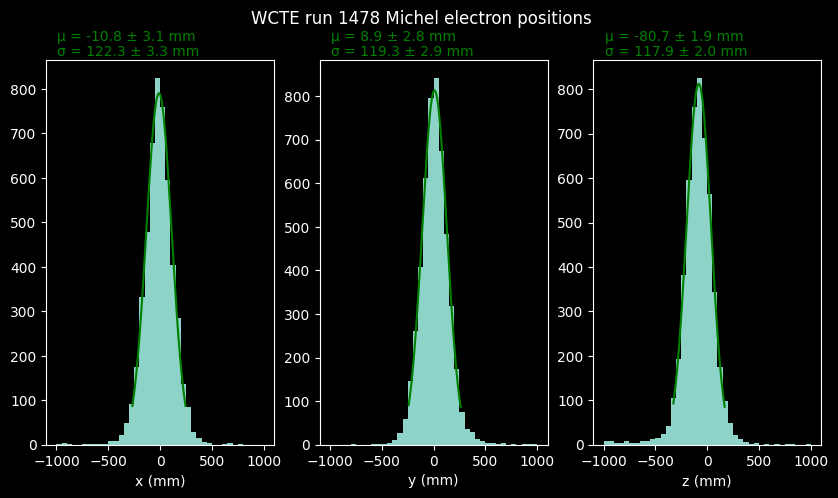

In [ ]:
# reset plot style to default 
plt.rcParams.update(plt.rcParamsDefault)
plt.style.use('dark_background')

def gauss(x, a, x0, sigma):
    return a * np.exp(-(x - x0)**2 / (2 * sigma**2))

labels = ['x', 'y', 'z']
bin_low = -1000
bin_high = 1000
bin_width = 50
bins = np.arange(bin_low, bin_high + bin_width, bin_width)
fig, axes = plt.subplots(1, 3, figsize=(10, 5))

for ax, data_label in zip(axes, labels):
    positions = np.array([m[data_label] for m in filtered])
    counts, edges = np.histogram(positions, bins=bins)
    bin_centers = edges[:-1] + 0.5 * np.diff(edges)

    # Find peak bin
    peak_idx = np.argmax(counts)
    peak_center = bin_centers[peak_idx]

    # Central region estimate
    mask = (positions > peak_center - 400) & (positions < peak_center + 400)
    mean = np.mean(positions[mask])
    std = np.std(positions[mask])

    # Fit range (±2σ)
    lower = mean - 2 * std
    upper = mean + 2 * std

    lower_bin = int((lower - bin_low) / bin_width)
    upper_bin = int((upper - bin_low) / bin_width)

    x_fit = bin_centers[lower_bin:upper_bin]
    y_fit = counts[lower_bin:upper_bin]

    fine_x = np.linspace(lower, upper, 200)

    # Gaussian fit
    popt, pcov = curve_fit(gauss, x_fit, y_fit, p0=[counts[peak_idx], mean, std])
    perr = np.sqrt(np.diag(pcov))

    # Plot
    ax.hist(positions, bins=bins)
    ax.plot(fine_x, gauss(fine_x, *popt), 'g')
    ax.set_xlabel(f'{data_label} (mm)')
    ax.text(0.05, 1.05,
            f'μ = {popt[1]:.1f} ± {perr[1]:.1f} mm',
            transform=ax.transAxes,
            color='g')
    ax.text(0.05, 1.01,
            f'σ = {popt[2]:.1f} ± {perr[2]:.1f} mm',
            transform=ax.transAxes,
            color='g')

fig.suptitle(f'WCTE run {run_number} Michel electron positions')
plt.show()